# setup

In [78]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds006848"
TARGET_SFREQ = 125
WINDOW_SEC = 0.25

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

band_edges = [1, 4, 8, 13, 30, 40]

# single fixed channel (robust choice)
CHANNEL = "Pz"

# feature functions

In [37]:
# def load_signal(file, channel):
#     try:
#         raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)
#
#         if channel not in raw.ch_names:
#             return None
#
#         if channel in raw.info["bads"]:
#             return None
#
#         raw.pick([channel])
#         raw.resample(TARGET_SFREQ)
#
#         x = raw.get_data()[0]
#
#         if not np.all(np.isfinite(x)):
#             return None
#
#         if np.std(x) < 1e-10:
#             return None
#
#         return x
#
#     except Exception:
#         return None

def load_signal(file, channel):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if channel not in raw.ch_names:
            return None
        if channel in raw.info["bads"]:
            return None

        raw.pick([channel])

        # ------------------------
        # FILTERING STEP (IMPORTANT)
        # ------------------------
        raw.notch_filter(50, verbose=False)   # remove mains noise
        raw.filter(1, 40, verbose=False)      # keep only <= 40 Hz

        raw.resample(TARGET_SFREQ)

        x = raw.get_data()[0]

        if not np.all(np.isfinite(x)):
            return None
        if np.std(x) < 1e-10:
            return None

        return x

    except Exception:
        return None


def bandpower(psd, freqs, band):
    fmin, fmax = band
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask])


def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    return entropy(psd / total)


def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

In [44]:
def spectral_complexity_alternative(psd, freqs):
    """True complexity measures"""

    # Option 1: Spectral edge frequency (frequency containing 95% power)
    cumsum = np.cumsum(psd)
    idx = np.where(cumsum >= 0.95 * cumsum[-1])[0]
    sef95 = freqs[idx[0]] if len(idx) > 0 else np.nan

    # Option 2: Number of spectral peaks
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(psd, height=np.mean(psd))
    n_peaks = len(peaks)

    # Option 3: Spectral rolloff rate
    rolloff_slope = np.polyfit(freqs, np.cumsum(psd)/np.sum(psd), 1)[0]

    return {
        "sef95": sef95,
        "n_peaks": n_peaks,
        "rolloff_slope": rolloff_slope
    }

# Or use Hjorth complexity
def hjorth_complexity(signal):
    """Temporal complexity, independent of spectral entropy"""
    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)
    mobility = np.std(diff1) / np.std(signal)
    complexity = (np.std(diff2) / np.std(diff1)) / mobility
    return complexity

In [45]:
# Test on synthetic spectra
flat_psd = np.ones(100)
spiky_psd = np.zeros(100)
spiky_psd[50] = 1

print(f"Flat - entropy: {spectral_entropy(flat_psd):.3f}, complexity: {spectral_complexity(flat_psd):.3f}")
print(f"Spiky - entropy: {spectral_entropy(spiky_psd):.3f}, complexity: {spectral_complexity(spiky_psd):.3f}")

Flat - entropy: 4.605, complexity: 0.000
Spiky - entropy: 0.000, complexity: 4.605


In [ ]:

print(f"Flat - entropy: {spectral_complexity_alternative(flat_psd):.3f}, complexity: {spectral_complexity(flat_psd):.3f}")
print(f"Spiky - entropy: {spectral_entropy(spiky_psd):.3f}, complexity: {spectral_complexity(spiky_psd):.3f}")

In [47]:

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    return entropy(psd / total)


def spectral_complexity(psd):
    """Original complexity measure (KL divergence from uniform)"""
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)


def spectral_complexity_alternative(psd, freqs):
    """Alternative complexity measures independent of entropy"""
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return {"sef95": np.nan, "n_peaks": np.nan, "rolloff_slope": np.nan}

    # Option 1: Spectral edge frequency (frequency containing 95% power)
    cumsum = np.cumsum(psd)
    cumsum_norm = cumsum / cumsum[-1]
    idx_95 = np.where(cumsum_norm >= 0.95)[0]
    sef95 = freqs[idx_95[0]] if len(idx_95) > 0 else np.nan

    # Option 2: Number of spectral peaks
    from scipy.signal import find_peaks
    psd_norm = psd / np.max(psd)
    peaks, _ = find_peaks(psd_norm, height=0.3 * np.max(psd_norm), distance=5)
    n_peaks = len(peaks)

    # Option 3: Spectral rolloff rate
    cumsum_norm_smooth = cumsum_norm
    rolloff_slope = np.polyfit(freqs, cumsum_norm_smooth, 1)[0]

    return {
        "sef95": sef95,
        "n_peaks": n_peaks,
        "rolloff_slope": rolloff_slope
    }


def hjorth_complexity(x):
    """Hjorth complexity (temporal complexity, independent of spectral entropy)"""
    if len(x) < 3:
        return np.nan

    # Activity (variance)
    activity = np.var(x)
    if activity == 0:
        return np.nan

    # Mobility (sqrt of variance of first derivative / variance of signal)
    diff1 = np.diff(x)
    mobility = np.sqrt(np.var(diff1) / activity)

    # Complexity (mobility of first derivative / mobility of signal)
    diff2 = np.diff(diff1)
    if len(diff2) > 0 and mobility > 0:
        complexity = (np.sqrt(np.var(diff2) / np.var(diff1))) / mobility
    else:
        complexity = np.nan

    return complexity

In [58]:


def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    return entropy(psd / total)


def spectral_complexity(psd):
    """Original complexity measure (KL divergence from uniform)"""
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)


def spectral_complexity_alternative(psd, freqs):
    """Alternative complexity measures independent of entropy"""
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return {"sef95": np.nan, "n_peaks": np.nan, "rolloff_slope": np.nan}

    # Option 1: Spectral edge frequency (frequency containing 95% power)
    cumsum = np.cumsum(psd)
    cumsum_norm = cumsum / cumsum[-1]
    idx_95 = np.where(cumsum_norm >= 0.95)[0]
    sef95 = freqs[idx_95[0]] if len(idx_95) > 0 else np.nan

    # Option 2: Number of spectral peaks
    from scipy.signal import find_peaks
    psd_norm = psd / np.max(psd)
    peaks, _ = find_peaks(psd_norm, height=0.3 * np.max(psd_norm), distance=5)
    n_peaks = len(peaks)

    # Option 3: Spectral rolloff rate
    cumsum_norm_smooth = cumsum_norm
    rolloff_slope = np.polyfit(freqs, cumsum_norm_smooth, 1)[0]

    return {
        "sef95": sef95,
        "n_peaks": n_peaks,
        "rolloff_slope": rolloff_slope
    }


def hjorth_activity(x):
    """Hjorth activity = variance of signal"""
    return np.var(x)


def hjorth_mobility(x):
    """Hjorth mobility = sqrt(var(diff(signal)) / var(signal))"""
    if len(x) < 2:
        return np.nan
    activity = np.var(x)
    if activity == 0:
        return np.nan
    diff1 = np.diff(x)
    mobility = np.sqrt(np.var(diff1) / activity)
    return mobility


def hjorth_complexity(x):
    """Hjorth complexity = mobility(diff(signal)) / mobility(signal)"""
    if len(x) < 3:
        return np.nan

    mobility_signal = hjorth_mobility(x)
    if np.isnan(mobility_signal) or mobility_signal == 0:
        return np.nan

    diff1 = np.diff(x)
    mobility_diff = hjorth_mobility(diff1)
    if np.isnan(mobility_diff):
        return np.nan

    complexity = mobility_diff / mobility_signal
    return complexity


def hjorth_all(x):
    """Return all Hjorth parameters (activity, mobility, complexity)"""
    activity = hjorth_activity(x)
    mobility = hjorth_mobility(x)
    complexity = hjorth_complexity(x)

    return {
        "activity": activity,
        "log_activity": np.log1p(activity) if activity > 0 else np.nan,
        "mobility": mobility,
        "complexity": complexity
    }

# selecting subjects

In [38]:
subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)

    rest = glob.glob(os.path.join(subj_path, "eeg", "*task-rest*_eeg.vhdr"))
    task = glob.glob(os.path.join(subj_path, "eeg", "*task-*_eeg.vhdr"))

    task = [t for t in task if "task-rest" not in t]

    if len(rest) > 0:
        rest_files[subj] = rest[0]
    if len(task) > 0:
        task_files[subj] = task[0]

subjects = sorted(rest_files.keys())
print("Subjects with REST:", len(subjects))

Subjects with REST: 9


# feat calc old

In [48]:
# rest_stats = {}
# task_stats = {}
#
# rest_signals = {}
# task_signals = {}
#
# FLAT_STD_THRESH = 1e-6
# FLAT_RANGE_THRESH = 1e-5
#
#
# def is_bad_signal(x):
#     if x is None:
#         return True
#     if not np.all(np.isfinite(x)):
#         return True
#     if np.std(x) < FLAT_STD_THRESH:
#         return True
#     if (np.max(x) - np.min(x)) < FLAT_RANGE_THRESH:
#         return True
#     return False
#
# valid_subjects = []
#
# for subj in subjects:
#
#     # --------------------
#     # LOAD REST
#     # --------------------
#     x_rest = load_signal(rest_files[subj], CHANNEL)
#
#     if is_bad_signal(x_rest):
#         continue
#
#     freqs_r, psd_r = welch(x_rest, fs=TARGET_SFREQ, nperseg=TARGET_SFREQ*2)
#
#     if np.sum(psd_r) <= 0 or not np.all(np.isfinite(psd_r)):
#         continue
#
#     # --------------------
#     # LOAD TASK
#     # --------------------
#     if subj not in task_files:
#         continue
#
#     x_task = load_signal(task_files[subj], CHANNEL)
#
#     if is_bad_signal(x_task):
#         continue
#
#     freqs_t, psd_t = welch(x_task, fs=TARGET_SFREQ, nperseg=TARGET_SFREQ*2)
#
#     if np.sum(psd_t) <= 0 or not np.all(np.isfinite(psd_t)):
#         continue
#
#     # --------------------
#     # if both valid → keep subject
#     # --------------------
#     rest_stats[subj] = {
#         "freqs": freqs_r,
#         "psd": psd_r,
#         "entropy": spectral_entropy(psd_r),
#         "complexity": spectral_complexity(psd_r),
#         "complexity_alt": spectral_complexity_alternative(psd_r, freqs_r),
#         "hjorth_complexity": hjorth_complexity(x_rest),
#         "bands": {k: bandpower(psd_r, freqs_r, v) for k, v in bands.items()}
#     }
#
#     task_stats[subj] = {
#         "freqs": freqs_t,
#         "psd": psd_t,
#         "entropy": spectral_entropy(psd_t),
#         "complexity": spectral_complexity(psd_t),
#         "complexity_alt": spectral_complexity_alternative(psd_t, freqs_t),
#         "hjorth_complexity": hjorth_complexity(x_task),
#         "bands": {k: bandpower(psd_t, freqs_t, v) for k, v in bands.items()}
#     }
#
#     rest_signals[subj] = x_rest
#     task_signals[subj] = x_task
#
#     valid_subjects.append(subj)
#
#
# print("VALID subjects:", len(valid_subjects))
# print("REST kept:", len(rest_stats))
# print("TASK kept:", len(task_stats))

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_50309/2008867778.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])


VALID subjects: 6
REST kept: 6
TASK kept: 6


# features calc

In [59]:
rest_stats = {}
task_stats = {}

rest_signals = {}
task_signals = {}

FLAT_STD_THRESH = 1e-6
FLAT_RANGE_THRESH = 1e-5


def is_bad_signal(x):
    if x is None:
        return True
    if not np.all(np.isfinite(x)):
        return True
    if np.std(x) < FLAT_STD_THRESH:
        return True
    if (np.max(x) - np.min(x)) < FLAT_RANGE_THRESH:
        return True
    return False


valid_subjects = []

for subj in subjects:

    # --------------------
    # LOAD REST
    # --------------------
    x_rest = load_signal(rest_files[subj], CHANNEL)

    if is_bad_signal(x_rest):
        continue

    freqs_r, psd_r = welch(x_rest, fs=TARGET_SFREQ, nperseg=TARGET_SFREQ*2)

    if np.sum(psd_r) <= 0 or not np.all(np.isfinite(psd_r)):
        continue

    # --------------------
    # LOAD TASK
    # --------------------
    if subj not in task_files:
        continue

    x_task = load_signal(task_files[subj], CHANNEL)

    if is_bad_signal(x_task):
        continue

    freqs_t, psd_t = welch(x_task, fs=TARGET_SFREQ, nperseg=TARGET_SFREQ*2)

    if np.sum(psd_t) <= 0 or not np.all(np.isfinite(psd_t)):
        continue

    # --------------------
    # Compute Hjorth features
    # --------------------
    hjorth_rest = hjorth_all(x_rest)
    hjorth_task = hjorth_all(x_task)

    # --------------------
    # Compute band powers (normalized and unnormalized)
    # --------------------
    bands_rest_raw = {k: bandpower(psd_r, freqs_r, v) for k, v in bands.items()}
    total_power_rest = sum(bands_rest_raw.values())
    bands_rest_norm = {k: v / total_power_rest if total_power_rest > 0 else np.nan
                       for k, v in bands_rest_raw.items()}

    bands_task_raw = {k: bandpower(psd_t, freqs_t, v) for k, v in bands.items()}
    total_power_task = sum(bands_task_raw.values())
    bands_task_norm = {k: v / total_power_task if total_power_task > 0 else np.nan
                       for k, v in bands_task_raw.items()}

    # --------------------
    # if both valid → keep subject
    # --------------------
    rest_stats[subj] = {
        "freqs": freqs_r,
        "psd": psd_r,

        # Spectral features
        "entropy": spectral_entropy(psd_r),
        "complexity": spectral_complexity(psd_r),
        "complexity_alt": spectral_complexity_alternative(psd_r, freqs_r),

        # Hjorth features (raw + log activity)
        "hjorth_activity": hjorth_rest["activity"],
        "hjorth_log_activity": hjorth_rest["log_activity"],
        "hjorth_mobility": hjorth_rest["mobility"],
        "hjorth_complexity": hjorth_rest["complexity"],

        # Band powers (raw and normalized)
        "bands_raw": bands_rest_raw,
        "bands_norm": bands_rest_norm,
        "total_power": total_power_rest,
    }

    task_stats[subj] = {
        "freqs": freqs_t,
        "psd": psd_t,

        # Spectral features
        "entropy": spectral_entropy(psd_t),
        "complexity": spectral_complexity(psd_t),
        "complexity_alt": spectral_complexity_alternative(psd_t, freqs_t),

        # Hjorth features (raw + log activity)
        "hjorth_activity": hjorth_task["activity"],
        "hjorth_log_activity": hjorth_task["log_activity"],
        "hjorth_mobility": hjorth_task["mobility"],
        "hjorth_complexity": hjorth_task["complexity"],

        # Band powers (raw and normalized)
        "bands_raw": bands_task_raw,
        "bands_norm": bands_task_norm,
        "total_power": total_power_task,
    }

    rest_signals[subj] = x_rest
    task_signals[subj] = x_task

    valid_subjects.append(subj)


print("VALID subjects:", len(valid_subjects))
print("REST kept:", len(rest_stats))
print("TASK kept:", len(task_stats))

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_50309/2008867778.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])


VALID subjects: 6
REST kept: 6
TASK kept: 6


# PLOT - power spectrum

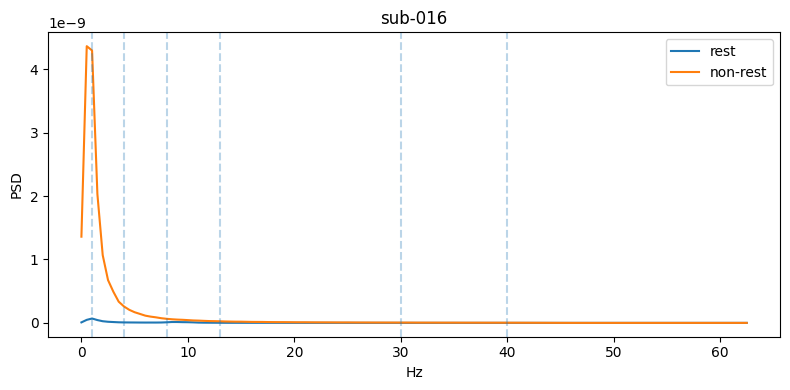

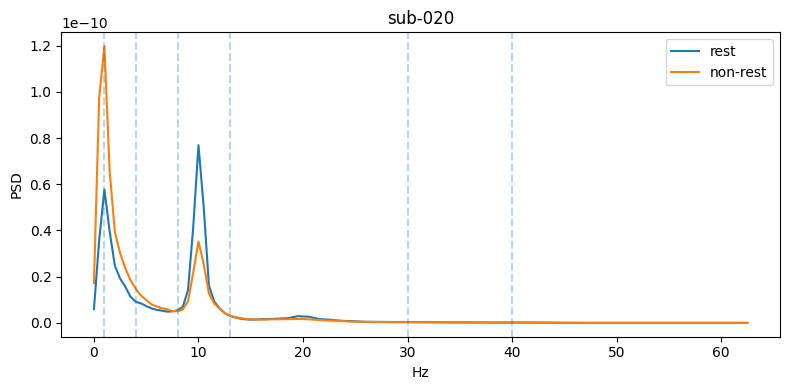

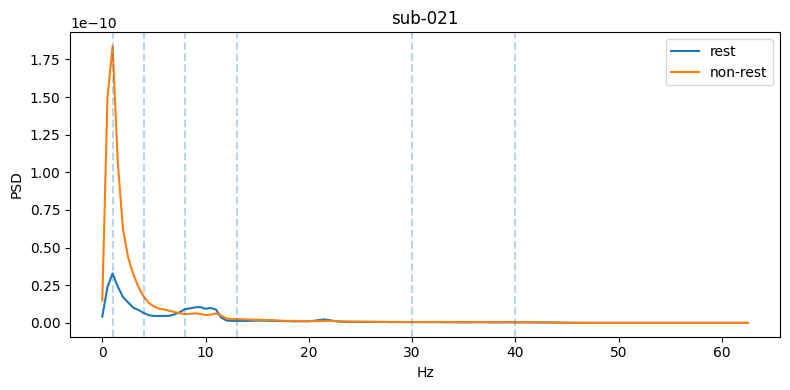

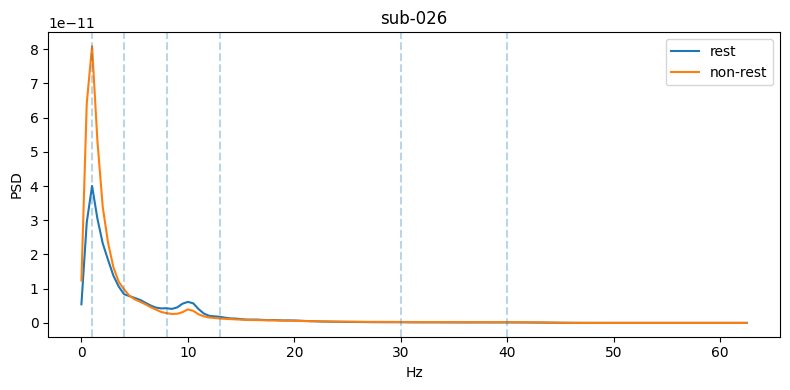

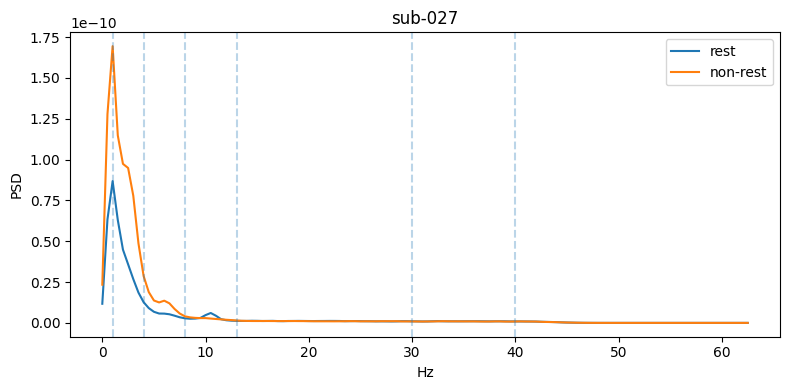

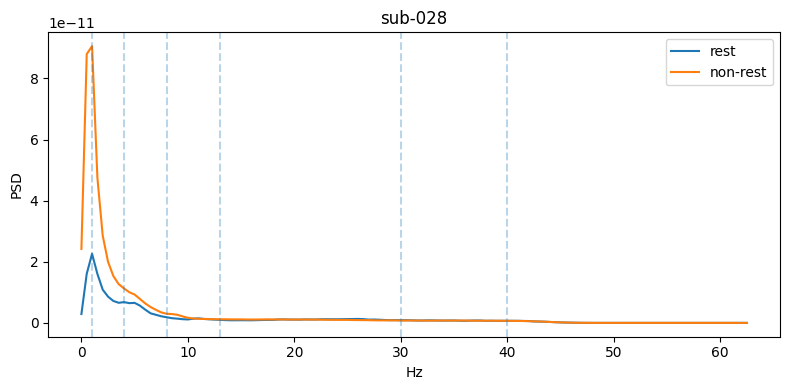

In [49]:
for subj in rest_stats.keys():

    plt.figure(figsize=(8,4))

    r = rest_stats[subj]
    plt.plot(r["freqs"], r["psd"], label="rest")

    if subj in task_stats:
        t = task_stats[subj]
        plt.plot(t["freqs"], t["psd"], label="non-rest")

    for b in band_edges:
        plt.axvline(b, linestyle="--", alpha=0.3)

    plt.title(subj)
    plt.xlabel("Hz")
    plt.ylabel("PSD")
    plt.legend()
    plt.tight_layout()
    plt.show()

# feature list

In [69]:
task_stats['sub-016'].keys()

dict_keys(['freqs', 'psd', 'entropy', 'complexity', 'complexity_alt', 'hjorth_activity', 'hjorth_log_activity', 'hjorth_mobility', 'hjorth_complexity', 'bands_raw', 'bands_norm', 'total_power'])

In [71]:
task_stats['sub-016']['bands_norm']

{'delta': np.float64(0.784837132000714),
 'theta': np.float64(0.11985186769870845),
 'alpha': np.float64(0.046572321290189574),
 'beta': np.float64(0.040820513819964634),
 'gamma': np.float64(0.00791816519042336)}

In [73]:
task_stats['sub-016']['bands_raw']

{'delta': np.float64(3.4385376542486532e-09),
 'theta': np.float64(5.250964094467207e-10),
 'alpha': np.float64(2.040432006496061e-10),
 'beta': np.float64(1.788433142528713e-10),
 'gamma': np.float64(3.4691158266715285e-11)}

In [72]:
task_stats['sub-016']['total_power']

np.float64(4.3812117368645664e-09)

# PLOT - bands_norm

## Normalized Band Power Differences: Task vs Rest - per subject

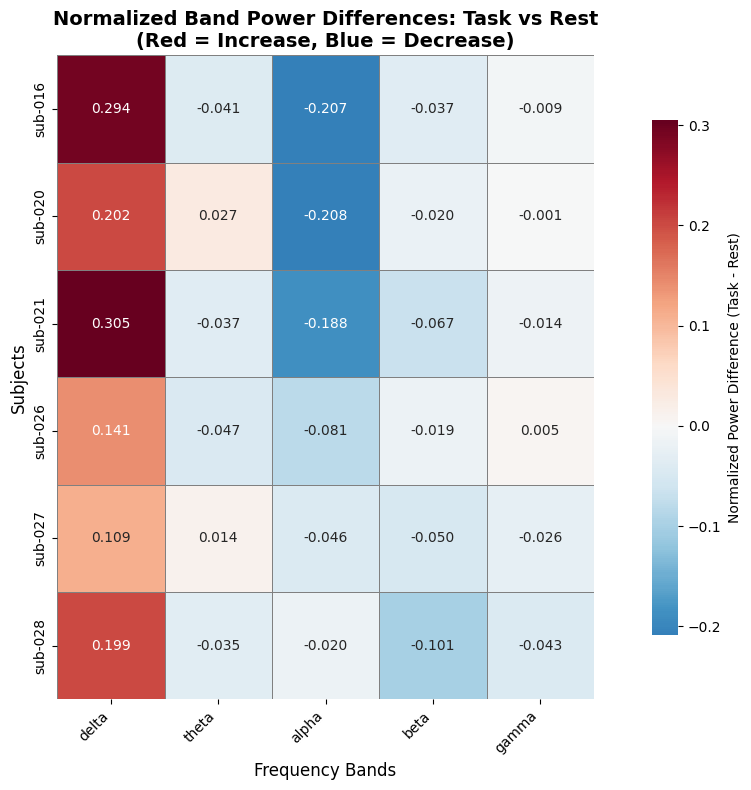

In [74]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for normalized band differences
bands_list = list(bands.keys())  # e.g., ['delta', 'theta', 'alpha', 'beta', 'gamma']
diff_matrix = []
subject_names = []

for subj in valid_subjects:
    # Get normalized band powers
    rest_bands = rest_stats[subj]["bands_norm"]
    task_bands = task_stats[subj]["bands_norm"]

    # Calculate difference (Task - Rest)
    band_diffs = [task_bands[band] - rest_bands[band] for band in bands_list]
    diff_matrix.append(band_diffs)
    subject_names.append(subj)

# Convert to DataFrame
df_diffs = pd.DataFrame(diff_matrix, columns=bands_list, index=subject_names)

# ============================================
# 1. HEATMAP OF DIFFERENCES (Recommended)
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
im = sns.heatmap(df_diffs,
                 annot=True,           # Show values
                 fmt='.3f',            # 3 decimal places
                 cmap='RdBu_r',        # Red-Blue colormap (red=increase, blue=decrease)
                 center=0,             # Center at zero
                 square=True,          # Square cells
                 linewidths=0.5,       # Grid lines
                 linecolor='gray',
                 cbar_kws={'label': 'Normalized Power Difference (Task - Rest)',
                          'shrink': 0.8},
                 ax=ax)

# Customize
ax.set_title('Normalized Band Power Differences: Task vs Rest\n(Red = Increase, Blue = Decrease)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency Bands', fontsize=12)
ax.set_ylabel('Subjects', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Group Statistics: Normalized Band Power Differences\n(Task - Rest)

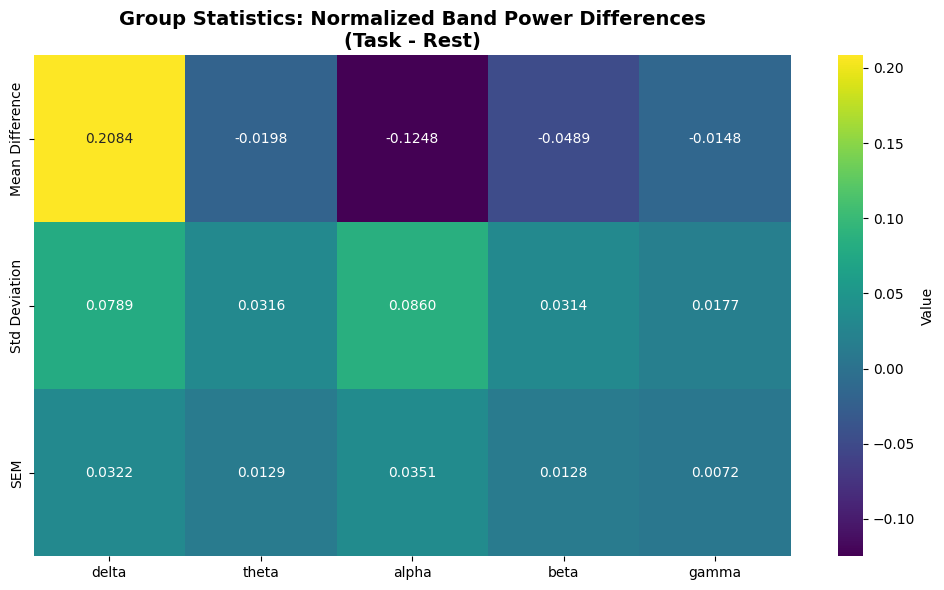

In [75]:
mean_diffs = df_diffs.mean()
std_diffs = df_diffs.std()
sem_diffs = std_diffs / np.sqrt(len(valid_subjects))  # Standard error

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Mean Difference': mean_diffs,
    'Std Deviation': std_diffs,
    'SEM': sem_diffs
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(summary_df.T,
            annot=True,
            fmt='.4f',
            cmap='viridis',
            cbar_kws={'label': 'Value'},
            ax=ax)
ax.set_title('Group Statistics: Normalized Band Power Differences\n(Task - Rest)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Mean Normalized Power Difference (Task - Rest)

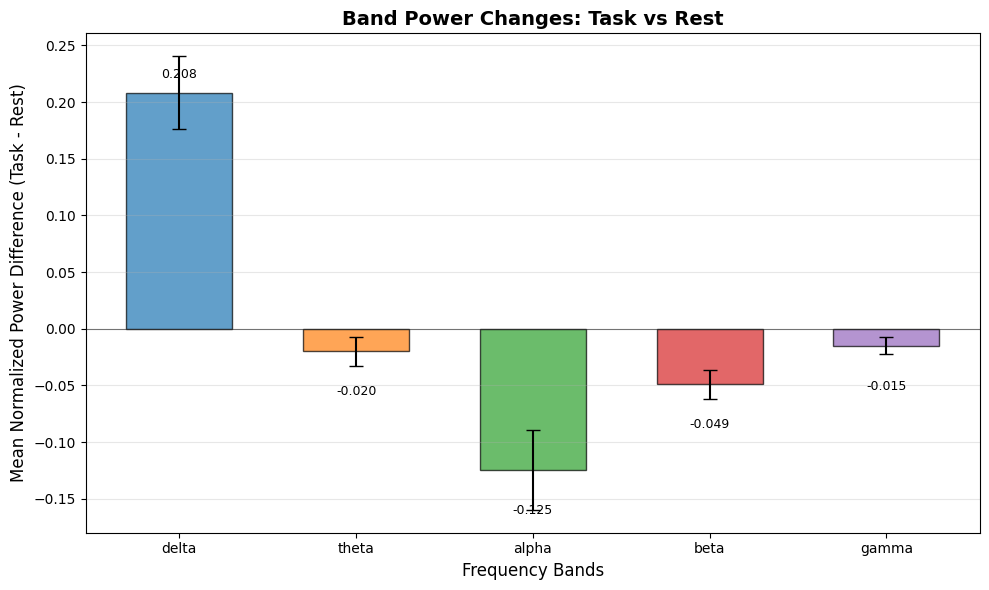

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(bands_list))
width = 0.6

bars = ax.bar(x_pos, mean_diffs, width,
              yerr=sem_diffs,
              capsize=5,
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(bands_list)],
              alpha=0.7,
              edgecolor='black',
              linewidth=1)

# Add significance stars (example: p < 0.05)
# You'd need to run statistical tests first
# for i, pval in enumerate(p_values):
#     if pval < 0.05:
#         ax.text(x_pos[i], mean_diffs[i] + sem_diffs[i] + 0.01, '*',
#                 ha='center', fontsize=14, fontweight='bold')

# Customize
ax.set_xlabel('Frequency Bands', fontsize=12)
ax.set_ylabel('Mean Normalized Power Difference (Task - Rest)', fontsize=12)
ax.set_title('Band Power Changes: Task vs Rest', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(bands_list)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, mean_diffs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.,
            height + (0.01 if height >= 0 else -0.03),
            f'{val:.3f}',
            ha='center',
            va='bottom' if height >= 0 else 'top',
            fontsize=9)

plt.tight_layout()
plt.show()

# PLOT - entropy-complexity plane

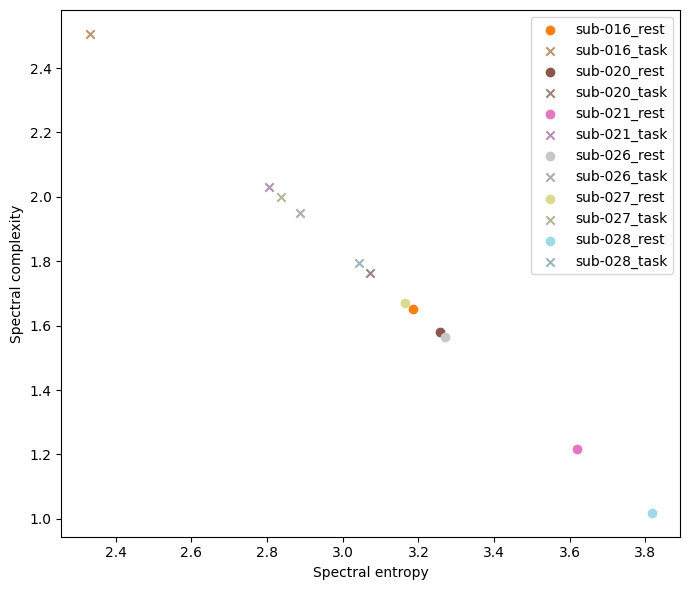

In [50]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["entropy"],
            rest_stats[subj]["complexity"],
            color=base,
            marker="o",
            label=subj + '_rest'
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["entropy"],
            task_stats[subj]["complexity"],
            color=base * 0.6,
            marker="x",
            label=subj + '_task'
        )

plt.xlabel("Spectral entropy")
plt.ylabel("Spectral complexity")
plt.tight_layout()
plt.legend()
plt.show()

In [54]:
rest_stats['sub-016']['complexity_alt']

{'sef95': np.float64(17.5),
 'n_peaks': 1,
 'rolloff_slope': np.float64(0.00624579776864538)}

In [56]:
rest_stats['sub-016']['hjorth_complexity']

np.float64(2.6642232098902756)

## using alternative formula

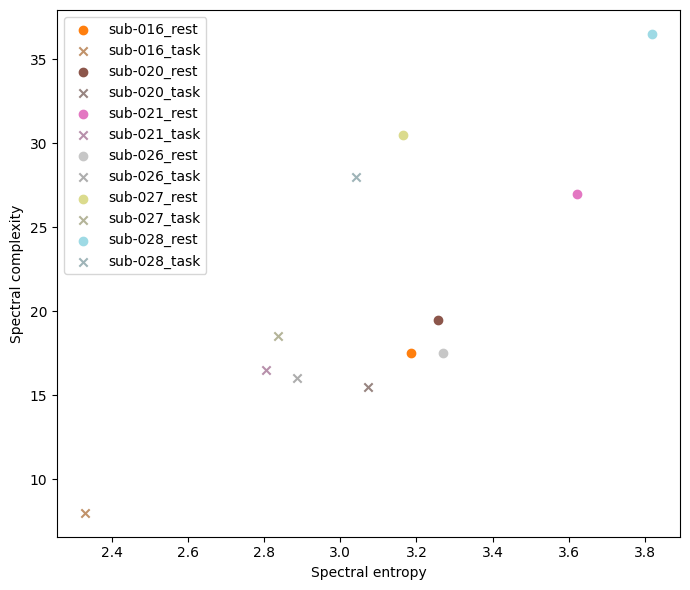

In [55]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["entropy"],
            rest_stats[subj]["complexity_alt"]['sef95'],
            color=base,
            marker="o",
            label=subj + '_rest'
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["entropy"],
            task_stats[subj]["complexity_alt"]['sef95'],
            color=base * 0.6,
            marker="x",
            label=subj + '_task'
        )

plt.xlabel("Spectral entropy")
plt.ylabel("Spectral complexity")
plt.tight_layout()
plt.legend()
plt.show()

## using hjorth formula

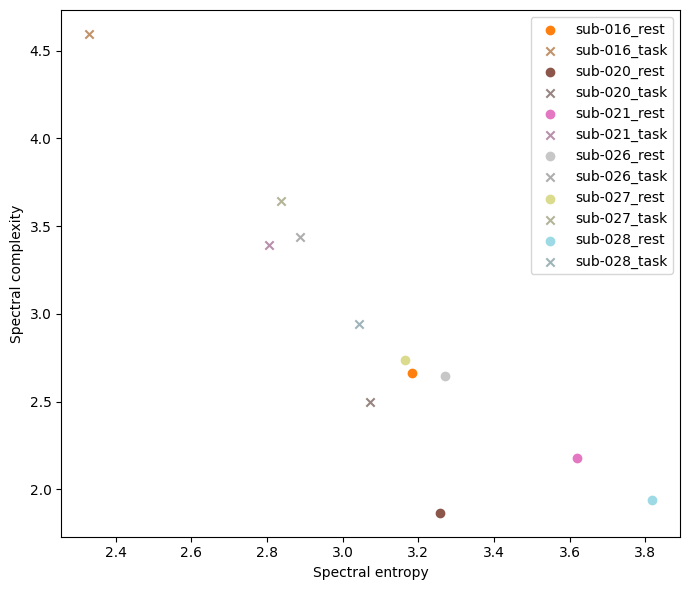

In [57]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["entropy"],
            rest_stats[subj]["hjorth_complexity"],
            color=base,
            marker="o",
            label=subj + '_rest'
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["entropy"],
            task_stats[subj]["hjorth_complexity"],
            color=base * 0.6,
            marker="x",
            label=subj + '_task'
        )

plt.xlabel("Spectral entropy")
plt.ylabel("Spectral complexity")
plt.tight_layout()
plt.legend()
plt.show()

# PLOT - hjorth complexity, mobility, etc pairings

## mobility - complexity

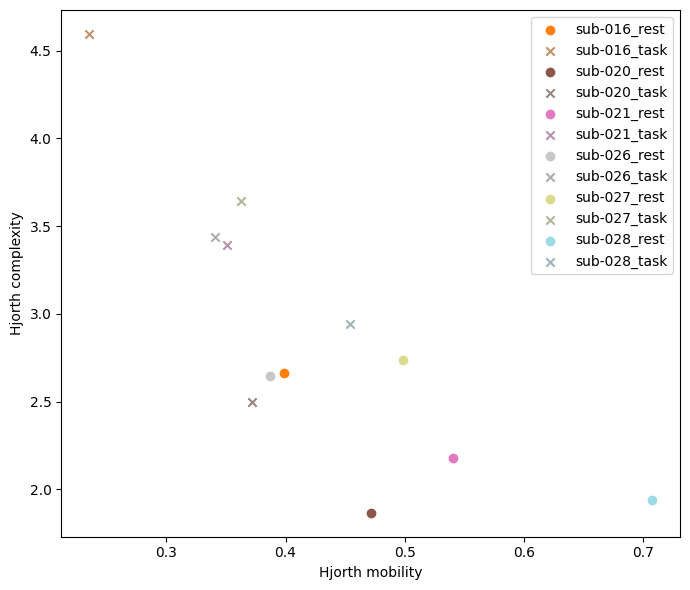

In [60]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["hjorth_mobility"],
            rest_stats[subj]["hjorth_complexity"],
            color=base,
            marker="o",
            label=subj + '_rest'
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["hjorth_mobility"],
            task_stats[subj]["hjorth_complexity"],
            color=base * 0.6,
            marker="x",
            label=subj + '_task'
        )

plt.xlabel("Hjorth mobility")
plt.ylabel("Hjorth complexity")
plt.tight_layout()
plt.legend()
plt.show()

## mobility - activity

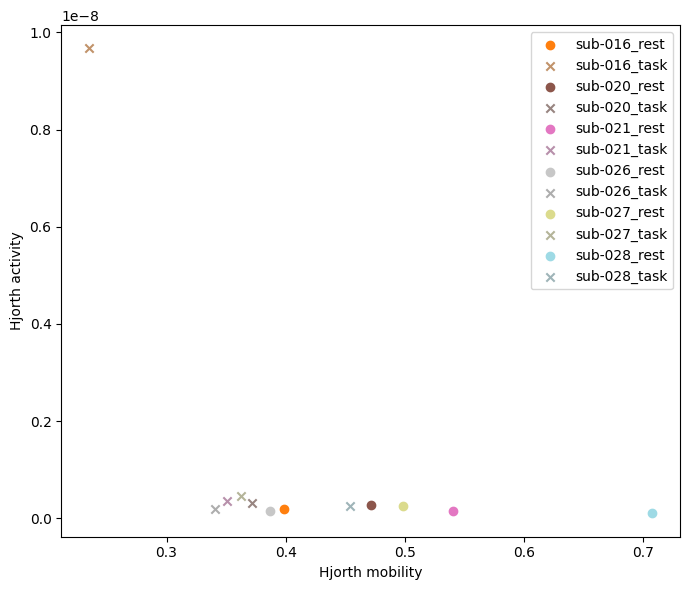

In [65]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["hjorth_mobility"],
            rest_stats[subj]["hjorth_activity"],
            color=base,
            marker="o",
            label=subj + '_rest'
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["hjorth_mobility"],
            task_stats[subj]["hjorth_activity"],
            color=base * 0.6,
            marker="x",
            label=subj + '_task'
        )

plt.xlabel("Hjorth mobility")
plt.ylabel("Hjorth activity")
plt.tight_layout()
plt.legend()
plt.show()

## complexity - activity

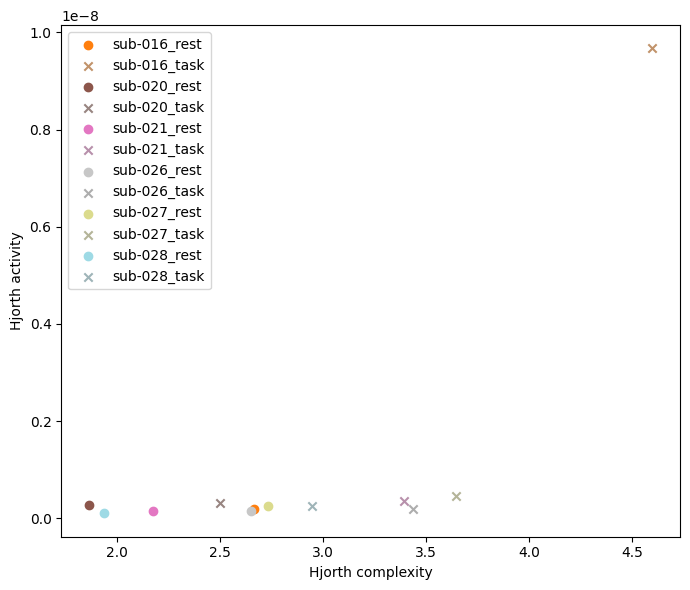

In [64]:
plt.figure(figsize=(7,6))

colors = plt.cm.tab20(np.linspace(0,1,len(subjects)))

for i, subj in enumerate(subjects):

    base = colors[i]

    if subj in rest_stats:
        plt.scatter(
            rest_stats[subj]["hjorth_complexity"],
            rest_stats[subj]["hjorth_activity"],
            color=base,
            marker="o",
            label=subj + '_rest'
        )

    if subj in task_stats:
        plt.scatter(
            task_stats[subj]["hjorth_complexity"],
            task_stats[subj]["hjorth_activity"],
            color=base * 0.6,
            marker="x",
            label=subj + '_task'
        )

plt.xlabel("Hjorth complexity")
plt.ylabel("Hjorth activity")
plt.tight_layout()
plt.legend()
plt.show()

# PLOT - signal visually - nothing special, just signal

## with offset, visually pleasing

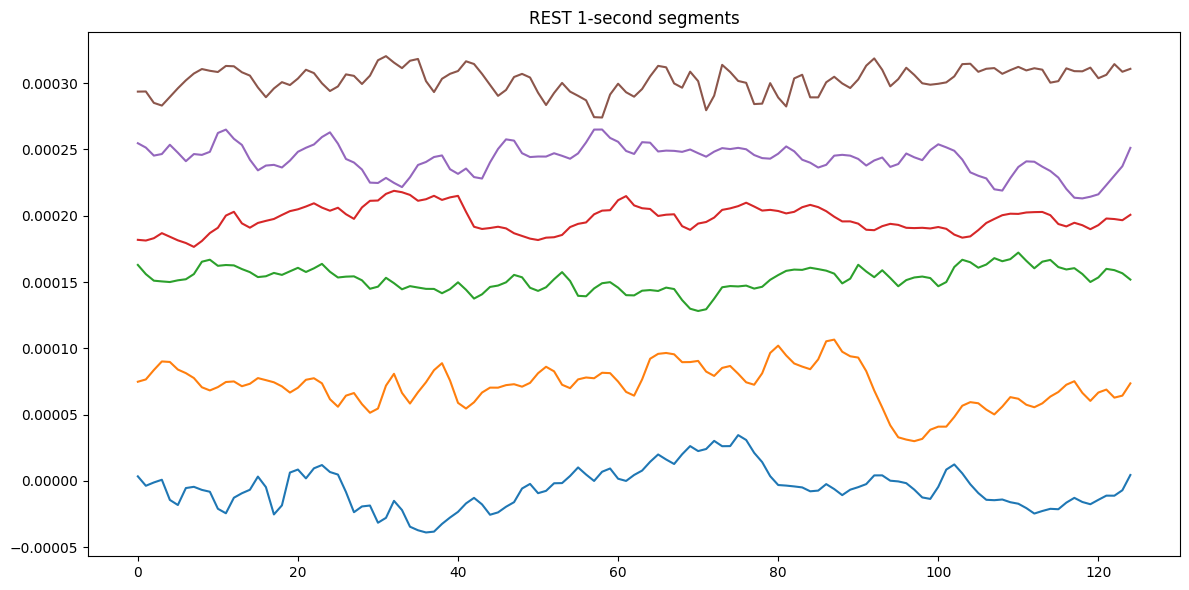

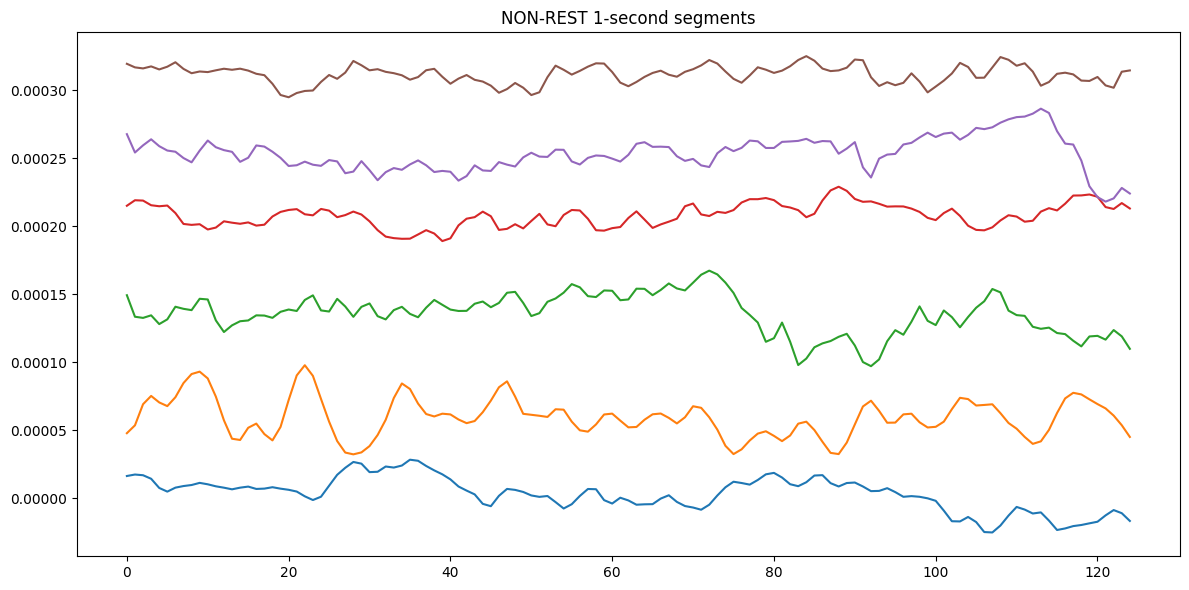

In [42]:
VIS_SEC = 1.0
vis_len = int(VIS_SEC * TARGET_SFREQ)

plt.figure(figsize=(12,6))
offset = 0

for subj, x in rest_signals.items():
    if len(x) > vis_len:
        start = np.random.randint(0, len(x)-vis_len)
        seg = x[start:start+vis_len]
        plt.plot(seg + offset)
        offset += np.std(seg) * 5

plt.title("REST 1-second segments")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,6))
offset = 0

for subj, x in task_signals.items():
    if len(x) > vis_len:
        start = np.random.randint(0, len(x)-vis_len)
        seg = x[start:start+vis_len]
        plt.plot(seg + offset)
        offset += np.std(seg) * 5

plt.title("NON-REST 1-second segments")
plt.tight_layout()
plt.show()

## on top of each other, no offset

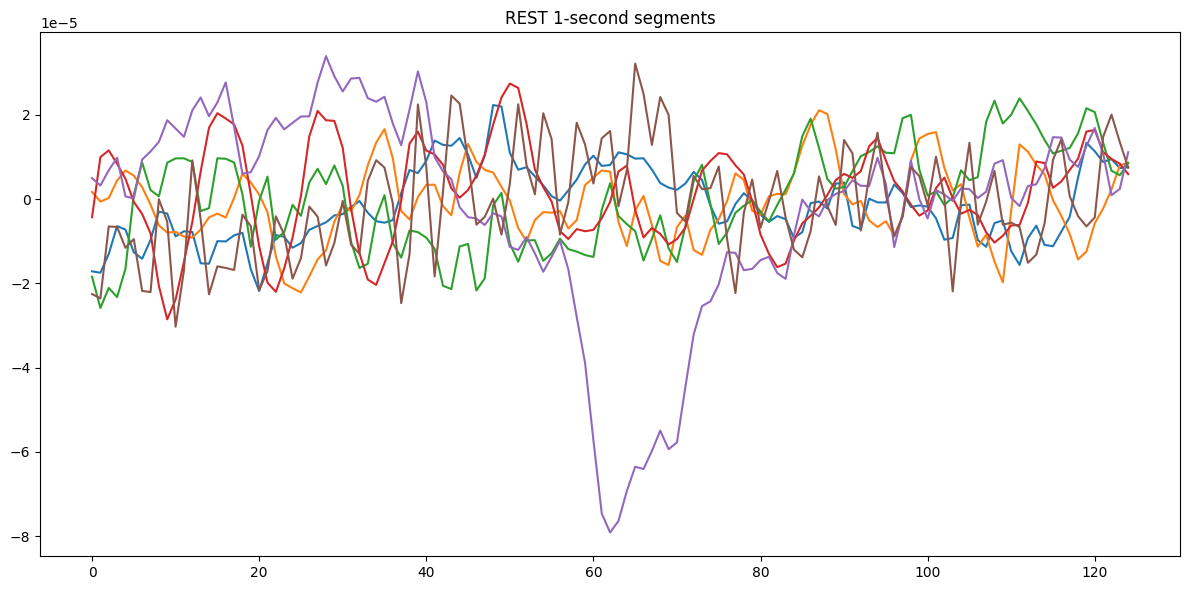

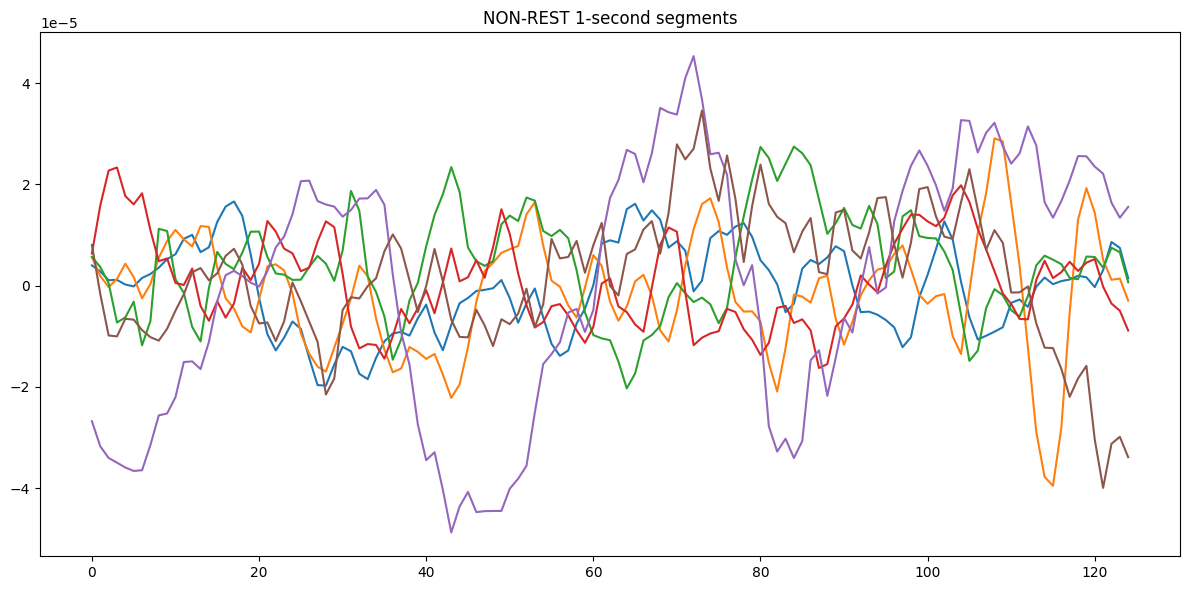

In [43]:
VIS_SEC = 1.0
vis_len = int(VIS_SEC * TARGET_SFREQ)

plt.figure(figsize=(12,6))
offset = 0

for subj, x in rest_signals.items():
    if len(x) > vis_len:
        start = np.random.randint(0, len(x)-vis_len)
        seg = x[start:start+vis_len]
        plt.plot(seg + offset)
        # offset += np.std(seg) * 5

plt.title("REST 1-second segments")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,6))
offset = 0

for subj, x in task_signals.items():
    if len(x) > vis_len:
        start = np.random.randint(0, len(x)-vis_len)
        seg = x[start:start+vis_len]
        plt.plot(seg + offset)
        # offset += np.std(seg) * 5

plt.title("NON-REST 1-second segments")
plt.tight_layout()
plt.show()